## 1. Import Library

In [33]:
import numpy  as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
from tensorflow.keras.models import load_model


## 2. ⚙️ Konfigurasi – Timesteps yang Mau diprediksi


In [38]:
JUMLAH_TIMESTEP = 120

WINDOW_SIZE = 48
DATA_PATH   = 'data6h.csv'
SAVE_DIR    = 'model_trial3'

print(f"Jumlah langkah prediksi : {JUMLAH_TIMESTEP:,} timestep")
print(f"  = {JUMLAH_TIMESTEP * 6 / 24:.1f} hari ke depan")
print(f"  = {JUMLAH_TIMESTEP * 6 / 24 / 365:.2f} tahun ke depan")

Jumlah langkah prediksi : 120 timestep
  = 30.0 hari ke depan
  = 0.08 tahun ke depan


## 3. Load Model, Scaler & Threshold


In [39]:
# ── Load model ────────────────────────────────────────────────────────────
MODEL_PATH  = os.path.join(SAVE_DIR, "lstm_trial3.keras")
model       = load_model(MODEL_PATH)
print(f"✅ Model berhasil dimuat dari : {MODEL_PATH}")

# ── Load scaler ───────────────────────────────────────────────────────────
SCALER_PATH = os.path.join(SAVE_DIR, "scaler_trial3.pkl")
with open(SCALER_PATH, "rb") as f:
    scaler = pickle.load(f)
print(f"✅ Scaler berhasil dimuat dari : {SCALER_PATH}")

# ── Load threshold (persentil 95) ─────────────────────────────────────────
THRESH_PATH = os.path.join(SAVE_DIR, "threshold_trial3.txt")
with open(THRESH_PATH, "r") as f:
    THRESHOLD = float(f.read().strip())
print(f"✅ Threshold (persentil 95) = {THRESHOLD:.4f} m")


✅ Model berhasil dimuat dari : model_trial3\lstm_trial3.keras
✅ Scaler berhasil dimuat dari : model_trial3\scaler_trial3.pkl
✅ Threshold (persentil 95) = 2.3330 m


## 4. Load Data & Ambil "Jendela Terakhir"
48 data terakhir (= 12 hari terakhir) dipakai sebagai titik mulai prediksi.


In [40]:
df = pd.read_csv(DATA_PATH, index_col='Time (UTC)', parse_dates=True)

print(f"Rentang data historis : {df.index.min()}  →  {df.index.max()}")
print(f"Total baris           : {len(df):,}")

# Normalisasi seluruh data menggunakan scaler yang sudah di-fit
data_scaled = scaler.transform(df[['prs(m)']].values)

# Ambil 48 data terakhir sebagai input awal prediksi
jendela_awal = data_scaled[-WINDOW_SIZE:].copy()

print(f"\nJendela awal (48 data terakhir):")
print(f"  Dari : {df.index[-WINDOW_SIZE]}")
print(f"  Sampai : {df.index[-1]}")


Rentang data historis : 2020-01-01 00:00:00  →  2026-01-01 00:00:00
Total baris           : 8,769

Jendela awal (48 data terakhir):
  Dari : 2025-12-20 06:00:00
  Sampai : 2026-01-01 00:00:00


## 5. Prediksi Rekursif (*Multi-step Forecasting*)

Cara kerja prediksi ke depan:
1. Model menerima **48 timestep terakhir** sebagai input.
2. Model menghasilkan **1 prediksi** (6 jam ke depan).
3. Prediksi tersebut **dimasukkan ke antrian** sebagai data terbaru.
4. Proses diulang sebanyak `JUMLAH_TIMESTEP` kali.


In [41]:
def prediksi_rekursif(model, jendela_awal: np.ndarray,
                      jumlah_langkah: int) -> np.ndarray:

    jendela   = jendela_awal.copy()
    prediksi  = []

    for langkah in range(jumlah_langkah):
        X_input = jendela.reshape(1, WINDOW_SIZE, 1)
        pred_scaled = model.predict(X_input, verbose=0)[0, 0]
        prediksi.append(pred_scaled)
        jendela = np.append(jendela[1:], [[pred_scaled]], axis=0)
        if (langkah + 1) % max(1, jumlah_langkah // 10) == 0:
            persen = (langkah + 1) / jumlah_langkah * 100
            print(f"  Progres prediksi : {persen:.0f}%  "
                  f"({langkah + 1:,} / {jumlah_langkah:,} langkah)")

    prediksi_asli = scaler.inverse_transform(
        np.array(prediksi).reshape(-1, 1)
    ).flatten()

    return prediksi_asli


print("⏳ Memulai prediksi, harap tunggu...")
hasil_prediksi = prediksi_rekursif(model, jendela_awal, JUMLAH_TIMESTEP)
print(f"\n✅ Prediksi selesai! Total: {len(hasil_prediksi):,} langkah.")


⏳ Memulai prediksi, harap tunggu...
  Progres prediksi : 10%  (12 / 120 langkah)
  Progres prediksi : 20%  (24 / 120 langkah)
  Progres prediksi : 30%  (36 / 120 langkah)
  Progres prediksi : 40%  (48 / 120 langkah)
  Progres prediksi : 50%  (60 / 120 langkah)
  Progres prediksi : 60%  (72 / 120 langkah)
  Progres prediksi : 70%  (84 / 120 langkah)
  Progres prediksi : 80%  (96 / 120 langkah)
  Progres prediksi : 90%  (108 / 120 langkah)
  Progres prediksi : 100%  (120 / 120 langkah)

✅ Prediksi selesai! Total: 120 langkah.


## 6. Setting Tabel


In [42]:
waktu_mulai = df.index[-1] + pd.Timedelta(hours=6)

indeks_waktu = pd.date_range(
    start=waktu_mulai,
    periods=JUMLAH_TIMESTEP,
    freq='24h'
)

def tentukan_kategori(nilai: float, threshold: float) -> str:
    return "⚠️ Potensi Rob" if nilai >= threshold else "✅ Normal"

kategori = [tentukan_kategori(v, THRESHOLD) for v in hasil_prediksi]

tabel_hasil = pd.DataFrame({
    "Waktu"           : indeks_waktu,
    "Hasil Prediksi (m)" : np.round(hasil_prediksi, 4),
    "Kategori"        : kategori
})

tabel_hasil.set_index("Waktu", inplace=True)

jumlah_rob    = (tabel_hasil["Kategori"] == "⚠️ Potensi Rob").sum()
jumlah_normal = (tabel_hasil["Kategori"] == "✅ Normal").sum()

print("=" * 50)
print("       RINGKASAN HASIL PREDIKSI")
print("=" * 50)
print(f"  Periode prediksi   : {indeks_waktu[0].date()} → {indeks_waktu[-1].date()}")
print(f"  Total timestep     : {JUMLAH_TIMESTEP:,}")
print(f"  Ambang batas (P95) : {THRESHOLD:.4f} m")
print(f"  ✅ Normal         : {jumlah_normal:,} kejadian")
print(f"  ⚠️ Potensi Rob    : {jumlah_rob:,} kejadian")
print("=" * 50)


       RINGKASAN HASIL PREDIKSI
  Periode prediksi   : 2026-01-01 → 2026-04-30
  Total timestep     : 120
  Ambang batas (P95) : 2.3330 m
  ✅ Normal         : 66 kejadian
  ⚠️ Potensi Rob    : 54 kejadian


## 7. Tampilkan Tabel Hasil Prediksi

In [43]:
print("── 10 Baris Pertama ──")
display(tabel_hasil.head(10))

print("\n── 10 Baris Terakhir ──")
display(tabel_hasil.tail(10))


── 10 Baris Pertama ──


,Hasil Prediksi (m),Kategori
Waktu,,
2026-01-01 06:00:00,2.2765,✅ Normal
2026-01-02 06:00:00,2.3511,⚠️ Potensi Rob
2026-01-03 06:00:00,2.2681,✅ Normal
2026-01-04 06:00:00,2.0134,✅ Normal
2026-01-05 06:00:00,2.2814,✅ Normal
2026-01-06 06:00:00,2.3632,⚠️ Potensi Rob
2026-01-07 06:00:00,2.2451,✅ Normal
2026-01-08 06:00:00,2.0397,✅ Normal
2026-01-09 06:00:00,2.2895,✅ Normal



── 10 Baris Terakhir ──


,Hasil Prediksi (m),Kategori
Waktu,,
2026-04-21 06:00:00,2.3135,✅ Normal
2026-04-22 06:00:00,2.3575,⚠️ Potensi Rob
2026-04-23 06:00:00,2.4039,⚠️ Potensi Rob
2026-04-24 06:00:00,2.3618,⚠️ Potensi Rob
2026-04-25 06:00:00,2.3208,✅ Normal
2026-04-26 06:00:00,2.3649,⚠️ Potensi Rob
2026-04-27 06:00:00,2.4065,⚠️ Potensi Rob
2026-04-28 06:00:00,2.3641,⚠️ Potensi Rob
2026-04-29 06:00:00,2.3281,✅ Normal


## 8. Simpan Tabel ke CSV

In [44]:
OUTPUT_CSV = f"prediksi_{JUMLAH_TIMESTEP}_timestep.csv"
tabel_hasil.to_csv(OUTPUT_CSV)
print(f"✅ Hasil prediksi disimpan ke : {OUTPUT_CSV}")


✅ Hasil prediksi disimpan ke : prediksi_120_timestep.csv


## 9. Visualisasi Hasil Prediksi

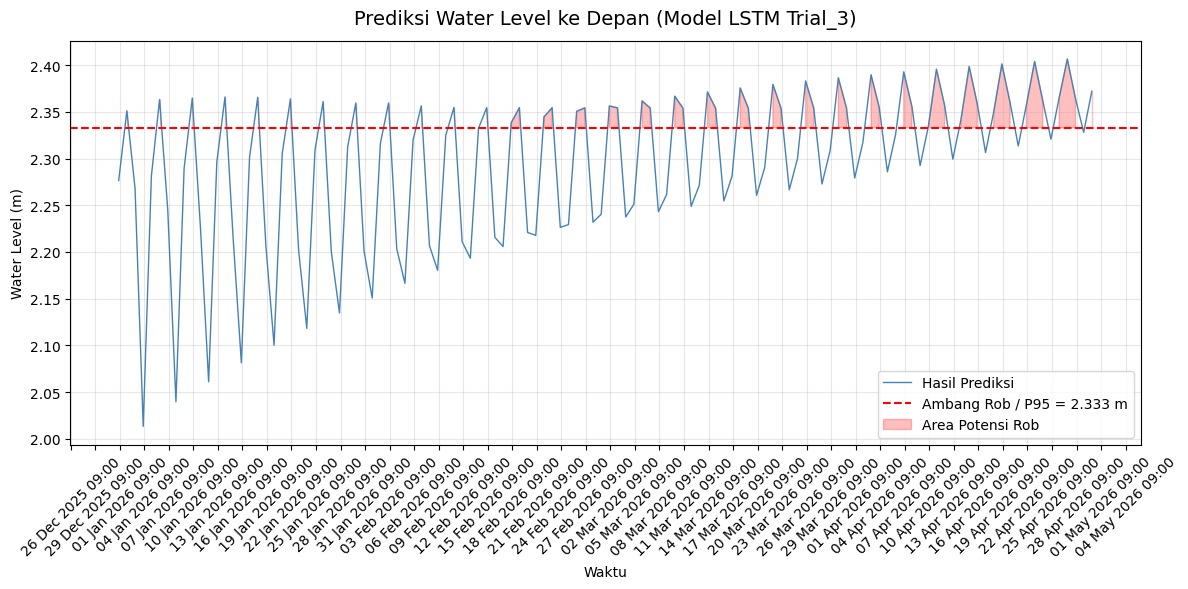

Grafik disimpan ke : prediksi_120_timestep.png


In [52]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(tabel_hasil.index, tabel_hasil["Hasil Prediksi (m)"],
        color='steelblue', linewidth=1, label='Hasil Prediksi')

ax.axhline(y=THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Ambang Rob / P95 = {THRESHOLD:.3f} m')

ax.fill_between(
    tabel_hasil.index,
    tabel_hasil["Hasil Prediksi (m)"],
    THRESHOLD,
    where=tabel_hasil["Hasil Prediksi (m)"] >= THRESHOLD,
    color='red', alpha=0.25, label='Area Potensi Rob'
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=72))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y %H:%M'))
plt.xticks(rotation=45)

ax.set_title('Prediksi Water Level ke Depan (Model LSTM Trial_3)',
             fontsize=14, pad=12)
ax.set_xlabel('Waktu')
ax.set_ylabel('Water Level (m)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"prediksi_{JUMLAH_TIMESTEP}_timestep.png", dpi=150,
            bbox_inches='tight')
plt.show()
print(f"Grafik disimpan ke : prediksi_{JUMLAH_TIMESTEP}_timestep.png")

## 10. Tabel Khusus: Waktu Berpotensi Rob
Menampilkan hanya baris yang melewati ambang batas.


In [46]:
tabel_rob = tabel_hasil[tabel_hasil["Kategori"] == "⚠️ Potensi Rob"].copy()

if tabel_rob.empty:
    print("✅ Tidak ada prediksi yang melewati ambang batas Rob.")
else:
    print(f"⚠️  Ditemukan {len(tabel_rob):,} kejadian Potensi Rob:\n")
    display(tabel_rob)

    # Simpan ke file terpisah
    tabel_rob.to_csv("prediksi_potensi_rob.csv")
    print("\n✅ Tabel Potensi Rob disimpan ke : prediksi_potensi_rob.csv")


⚠️  Ditemukan 54 kejadian Potensi Rob:



,Hasil Prediksi (m),Kategori
Waktu,,
2026-01-02 06:00:00,2.3511,⚠️ Potensi Rob
2026-01-06 06:00:00,2.3632,⚠️ Potensi Rob
2026-01-10 06:00:00,2.3647,⚠️ Potensi Rob
2026-01-14 06:00:00,2.3659,⚠️ Potensi Rob
2026-01-18 06:00:00,2.3655,⚠️ Potensi Rob
2026-01-22 06:00:00,2.3639,⚠️ Potensi Rob
2026-01-26 06:00:00,2.3609,⚠️ Potensi Rob
2026-01-30 06:00:00,2.3595,⚠️ Potensi Rob
2026-02-03 06:00:00,2.3595,⚠️ Potensi Rob



✅ Tabel Potensi Rob disimpan ke : prediksi_potensi_rob.csv
